# Coding Challenge: Comparing Returns (Boeing)

This notebook solves the challenge using Boeing (BA) prices from `close.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')

## 1) Calculate Daily Log Returns for Boeing

In [2]:
close_prices = pd.read_csv('close.csv', index_col='Date', parse_dates=['Date'])

if 'BA' not in close_prices.columns:
    raise ValueError("Column 'BA' not found in close.csv")

boeing = close_prices[['BA']].dropna().rename(columns={'BA': 'Close'})
boeing['Log_Return_Daily'] = np.log(boeing['Close'] / boeing['Close'].shift(1))
boeing = boeing.dropna(subset=['Log_Return_Daily']).copy()

boeing.head()

,Close,Log_Return_Daily
Date,,
2014-10-02,107.971878,-0.004019
2014-10-03,109.876221,0.017484
2014-10-06,109.789253,-0.000792
2014-10-07,107.232780,-0.023561
2014-10-08,108.676231,0.013371


## 2) Annualized Mean and Annualized Std from Daily Log Returns

Assumption: 252 trading days per year.

In [3]:
trading_days_per_year = 252

daily_mean_log = boeing['Log_Return_Daily'].mean()
daily_std_log = boeing['Log_Return_Daily'].std(ddof=1)

annualized_mean_daily = daily_mean_log * trading_days_per_year
annualized_std_daily = daily_std_log * np.sqrt(trading_days_per_year)

print('From Daily Log Returns:')
print(f'  Daily mean log return:          {daily_mean_log:.8f}')
print(f'  Daily std log return:           {daily_std_log:.8f}')
print(f'  Annualized mean log return:     {annualized_mean_daily:.8f}')
print(f'  Annualized std (volatility):    {annualized_std_daily:.8f}')

From Daily Log Returns:
  Daily mean log return:          0.00049140
  Daily std log return:           0.02632028
  Annualized mean log return:     0.12383180
  Annualized std (volatility):    0.41782153


## 3) Resample to Monthly Prices and Compare Annualized Std

Monthly close = last available price in each month (`ME`).

For monthly log returns, annualization uses 12 periods/year.

In [4]:
boeing_monthly = boeing[['Close']].resample('ME').last().dropna()
boeing_monthly['Log_Return_Monthly'] = np.log(boeing_monthly['Close'] / boeing_monthly['Close'].shift(1))
boeing_monthly = boeing_monthly.dropna(subset=['Log_Return_Monthly']).copy()

monthly_std_log = boeing_monthly['Log_Return_Monthly'].std(ddof=1)
annualized_std_monthly = monthly_std_log * np.sqrt(12)

comparison = pd.DataFrame({
    'Metric': [
        'Annualized Std from Daily Log Returns',
        'Annualized Std from Monthly Log Returns',
        'Difference (Monthly - Daily)'
    ],
    'Value': [
        annualized_std_daily,
        annualized_std_monthly,
        annualized_std_monthly - annualized_std_daily
    ]
})

comparison

,Metric,Value
0,Annualized Std from Daily Log Returns,0.417822
1,Annualized Std from Monthly Log Returns,0.407117
2,Difference (Monthly - Daily),-0.010705


Interpretation: the monthly-based annualized volatility can differ from the daily-based one because lower-frequency sampling smooths intra-month moves and uses fewer observations.

## 4) Monthly Data: Rolling 36-Month Mean Return (Annualized)

We compute a rolling mean of monthly log returns over 36 months, then annualize by multiplying by 12.

In [5]:
rolling_window_months = 36
boeing_monthly['Rolling_36M_Mean_Ann'] = boeing_monthly['Log_Return_Monthly'].rolling(rolling_window_months).mean() * 12

boeing_monthly[['Log_Return_Monthly', 'Rolling_36M_Mean_Ann']].tail()

,Log_Return_Monthly,Rolling_36M_Mean_Ann
Date,,
2021-01-31,-0.097419,-0.184452
2021-02-28,0.087796,-0.164122
2021-03-31,0.183531,-0.069753
2021-04-30,-0.083520,-0.103318
2021-05-31,0.052824,-0.105456


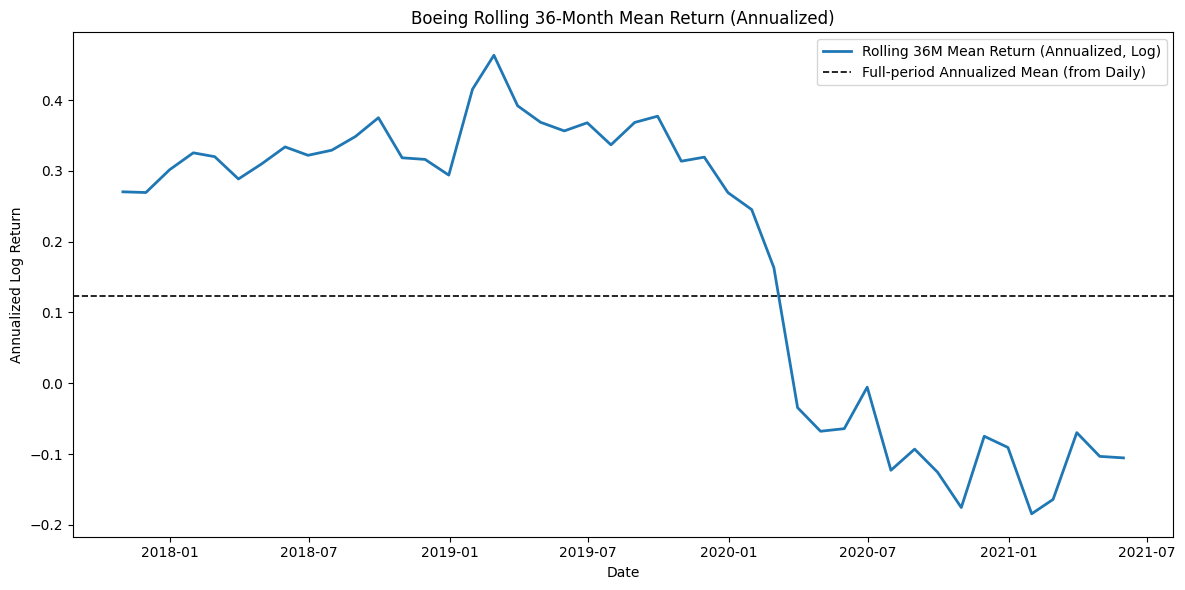

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(
    boeing_monthly.index,
    boeing_monthly['Rolling_36M_Mean_Ann'],
    linewidth=2,
    label='Rolling 36M Mean Return (Annualized, Log)'
)

plt.axhline(annualized_mean_daily, color='black', linestyle='--', linewidth=1.2, label='Full-period Annualized Mean (from Daily)')
plt.title('Boeing Rolling 36-Month Mean Return (Annualized)')
plt.xlabel('Date')
plt.ylabel('Annualized Log Return')
plt.legend()
plt.tight_layout()
plt.show()

This rolling series highlights how estimated return changes through time depending on the sample window, rather than being constant over the whole period.